# Reinforcement Learning op Taxi-v4
## Projectwalkthrough voor de docent

Dit notebook neemt je stap voor stap mee door het volledige RL-project:  
van het begrijpen van de omgeving tot het trainen, vergelijken en visualiseren van agents.

| # | Sectie | Wat je ziet |
|---|---|---|
| 1 | Setup | Dependencies installeren, modules importeren |
| 2 | De omgeving | Taxi-v4: states, actions, rewards en state-decoding |
| 3 | Agents | Overzicht en theorie van alle vier agents |
| 4 | Baselines | Random en rule-based agent evalueren |
| 5 | Q-learning | Theorie, training en greedy evaluatie |
| 5b | Hyperparameter-sweeps | α, γ, ε-decay voor Q-learning; α voor SARSA |
| 6 | SARSA | Theorie, training en greedy evaluatie |
| 7 | Vergelijking | Alle vier agents naast elkaar |
| 8 | Policy visualisatie | Wat heeft de agent geleerd? |
| 9 | Unit tests | Smoketests draaien via pytest |
| 10 | Conclusie | Samenvatting van bevindingen + hyperparameter-inzichten |

## 1 — Setup

Installeer de benodigde packages en stel de importpaden in.  
De broncode staat in `src/`, resultaten worden opgeslagen in `results/notebook_demo/`.

In [1]:
from pathlib import Path
import sys, subprocess

# Zoek requirements.txt in huidige map of een map hoger.
req = Path("requirements.txt")
if not req.exists():
    req = Path("..") / "requirements.txt"

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(req)],
    capture_output=True, text=True
)
if result.returncode != 0:
    print(result.stderr)
else:
    print("✓ Packages geïnstalleerd")


✓ Packages geïnstalleerd


In [2]:
import sys
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import yaml

# Voeg projectroot toe aan het importpad zodat src/ gevonden wordt.
PROJECT_ROOT = Path("..").resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.env import TaxiEnv, N_ACTIONS, N_STATES, ACTION_NAMES, LOCATIONS, LOC_NAMES, decode_state
from src.agents.q_learning import QLearningAgent
from src.agents.sarsa import SarsaAgent
from src.agents.random_agent import RandomAgent
from src.agents.rule_based_agent import RuleBasedAgent

# Dict om evaluatieresultaten per agent bij te houden.
results = {}

RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_demo"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Imports geslaagd")
print(f"  PROJECT_ROOT : {PROJECT_ROOT}")
print(f"  States       : {N_STATES}")
print(f"  Actions      : {N_ACTIONS}  →  {ACTION_NAMES}")
print(f"  Results dir  : {RESULTS_DIR}")


✓ Imports geslaagd
  PROJECT_ROOT : C:\Users\srlam\Documents\GitHub\Autonomous_2
  States       : 500
  Actions      : 6  →  ('south', 'north', 'east', 'west', 'pickup', 'dropoff')
  Results dir  : C:\Users\srlam\Documents\GitHub\Autonomous_2\results\notebook_demo


## 2 — De omgeving: Taxi-v4

Taxi-v4 is een discrete gridworld uit Gymnasium. Een taxi rijdt op een **5×5 grid** en moet een passagier ophalen en afleveren bij één van vier locaties.

```
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
```

Vier vaste locaties: **R** (rood), **G** (groen), **Y** (geel), **B** (blauw).

### State space — 500 discrete states

```
state = (taxi_row * 5 + taxi_col) * 20 + passenger_loc * 4 + destination
```

| Component | Betekenis | Waarden |
|---|---|---|
| `taxi_row` | Rij van de taxi | 0–4 |
| `taxi_col` | Kolom van de taxi | 0–4 |
| `passenger_loc` | Locatie passagier | 0=R, 1=G, 2=Y, 3=B, 4=in_taxi |
| `destination` | Bestemming | 0=R, 1=G, 2=Y, 3=B |

### Action space — 6 actions

| Index | Action | Omschrijving |
|---|---|---|
| 0 | south | Rij naar beneden |
| 1 | north | Rij naar boven |
| 2 | east | Rij naar rechts |
| 3 | west | Rij naar links |
| 4 | pickup | Passagier oppakken |
| 5 | dropoff | Passagier afzetten |

### Rewards

| Situatie | Reward |
|---|---|
| Elke stap | −1 |
| Ongeldige pickup of dropoff | −10 |
| Succesvolle aflevering | +20 (episode klaar) |

In [4]:
# Reset de omgeving en toon de begin-state (gedecodeerd).
env = TaxiEnv()
s0 = env.reset(seed=42)
dec = decode_state(s0)

print("=== Begin-state ===")
print(f"  Integer state : {s0}")
# decode_state geeft een tuple (taxi_row, taxi_col, passenger_loc, destination)
taxi_row, taxi_col, passenger_loc, destination = dec
print(f"  taxi_row      : {taxi_row}")
print(f"  taxi_col      : {taxi_col}")
print(f"  passenger_loc : {passenger_loc}  ({LOC_NAMES[passenger_loc]})")
print(f"  destination   : {destination}  ({LOC_NAMES[destination]})")

print("\n=== Effect van elke action vanuit de begin-state ===")
print(f"{'Idx':<5} {'Action':<10} {'→ State':<9} {'Reward':<9} {'Done':<7} {'Flags'}")
print("-" * 56)
for a_idx, a_name in enumerate(ACTION_NAMES):
    env.reset(seed=42)
    s1, r, done, info = env.step(a_idx)
    flags = []
    if info.get("illegal_action"):
        flags.append("ILLEGAL")
    if info.get("delivered"):
        flags.append("DELIVERED")
    print(f"{a_idx:<5} {a_name:<10} {s1:<9} {r:<9.0f} {str(done):<7} {', '.join(flags) or '-'}")

env.close()


=== Begin-state ===
  Integer state : 386
  taxi_row      : 3
  taxi_col      : 4
  passenger_loc : 1  (G)
  destination   : 2  (Y)

=== Effect van elke action vanuit de begin-state ===
Idx   Action     → State   Reward    Done    Flags
--------------------------------------------------------
0     south      486       -1        False   -
1     north      286       -1        False   -
2     east       386       -1        False   -
3     west       366       -1        False   -
4     pickup     386       -10       False   ILLEGAL
5     dropoff    386       -10       False   ILLEGAL


## 3 — De agents: overzicht & theorie

Het project bevat vier agents, van eenvoudig naar complex:

| Agent | Klasse | Leert? | Strategie |
|---|---|---|---|
| Random | `RandomAgent` | ✗ | Willekeurige action elke stap |
| Rule-based | `RuleBasedAgent` | ✗ | Vaste heuristiek (Manhattan-afstand) |
| Q-learning | `QLearningAgent` | ✓ | Off-policy, epsilon-greedy |
| SARSA | `SarsaAgent` | ✓ | On-policy, epsilon-greedy |

---

### Q-learning (off-policy)

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$

- **Off-policy**: we leren de *optimale* policy, ongeacht welke action de agent werkelijk kiest.
- De term $\max_{a'} Q(s',a')$ kijkt altijd naar de beste mogelijke volgende action.
- Epsilon-greedy: met kans $\varepsilon$ een willekeurige action (exploration), anders de beste (exploitation).

### SARSA (on-policy)

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma Q(s',a') - Q(s,a)\bigr]$$

- **On-policy**: we leren de policy die de agent *daadwerkelijk volgt*, inclusief willekeurige keuzes.
- $a'$ is de werkelijk gekozen volgende action — ook als die suboptimaal is.
- SARSA is conservatiever: het rekent de kosten van exploration in, Q-learning niet.

### Gemeenschappelijke hyperparameters

| Parameter | Symbool | Betekenis | Standaard |
|---|---|---|---|
| Learning rate | $\alpha$ | Hoe snel nieuwe info de Q-table overschrijft | 0.5 |
| Discount factor | $\gamma$ | Gewicht van toekomstige rewards | 0.99 |
| Epsilon start | $\varepsilon_0$ | Beginwaarde exploration | 1.0 |
| Epsilon end | $\varepsilon_\infty$ | Eindwaarde exploration | 0.05 |
| Epsilon decay | — | Episodes totdat $\varepsilon$ zijn eindwaarde bereikt | 2000 |

## 4 — Baselines: Random & Rule-Based

We evalueren eerst de twee baselines over 100 episodes. Dit geeft ons een referentiepunt voor de RL-agents.

- **RandomAgent** — kiest elke stap een willekeurige action. Verwachte return is sterk negatief.
- **RuleBasedAgent** — volgt een vaste heuristiek: ga naar de passagier → pickup → ga naar bestemming → dropoff. Weet niets van muren (loopt er soms tegenaan), maar haalt wel consequent de passagier op en levert af.

Op Taxi-v4 zijn episodes kort (doorgaans 10-20 stappen na convergentie). Het verschil tussen γ = 0.8 en γ = 0.99 is daardoor in de praktijk beperkt: `0.99^15 ≈ 0.86` vs `0.8^15 ≈ 0.04`. Bij γ = 0.8 verdisconteert de afleveringsbeloning van +20 tot bijna nul na 15 stappen, wat de agent mogelijk minder "gemotiveerd" maakt om snel af te leveren.

**Verwacht resultaat:** Kleine verschillen tussen de γ-waarden, met γ = 0.99 marginaal beter.

## 5 — Training: Q-learning

We laden de hyperparameters uit `experiments/qlearning_default.yaml` en trainen de agent voor **2 000 episodes**.  
De Q-table (500 × 6 floats) wordt bij elke stap bijgewerkt via de Bellman-regel.

**Epsilon-decay**: ε daalt lineair van 1.0 naar 0.05 over de eerste 2 000 episodes.  
Dit zorgt voor veel exploration aan het begin en meer exploitation naarmate de training vordert.

In [ ]:
# Create the sweep if it does not exist yet
if "sweep_alpha_ql" not in globals():
    base_cfg = globals().get("ql_cfg", globals().get("qlearning_cfg", None))
    if base_cfg is None:
        raise NameError("Missing sweep_alpha_ql and no Q-learning base config found.")

    sweep_alpha_ql = run_sweep(
        QLearningAgent,
        param_name="alpha",
        param_values=[0.1, 0.3, 0.5, 0.9],
        base_cfg=base_cfg,
        n_seeds=3,
        episodes=3000,
    )

# Create the plotting helper if it does not exist yet
if "plot_sweep" not in globals():
    def plot_sweep(sweep_results, param_label, title, color_map=None, window=50):
        fig, ax = plt.subplots(figsize=(11, 4.5))
        colors = color_map or plt.cm.tab10.colors
        for i, (val, seed_logs) in enumerate(sweep_results.items()):
            arr = np.stack([lg[:, 1] for lg in seed_logs], axis=0)
            mean_r = arr.mean(axis=0)
            std_r = arr.std(axis=0)
            smooth = np.convolve(mean_r, np.ones(window) / window, mode="valid")
            x = np.arange(window - 1, len(mean_r))
            c = colors[i % len(colors)]
            ax.plot(x, smooth, color=c, linewidth=2, label=f"{param_label}={val}")
            ax.fill_between(
                x,
                np.convolve(mean_r - std_r, np.ones(window) / window, mode="valid"),
                np.convolve(mean_r + std_r, np.ones(window) / window, mode="valid"),
                alpha=0.15,
                color=c,
            )
        ax.set_xlabel("Episode")
        ax.set_ylabel(f"Return (voortschrijdend gemiddelde, w={window})")
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"sweep_{param_label.replace(' ', '_')}.png", dpi=110)
        plt.show()
        return fig

plot_sweep(sweep_alpha_ql, "alpha", "Q-learning: sweep over leersnelheid α — Taxi-v4")

NameError: name 'plot_sweep' is not defined

### Q-learning: training curve

De ruwe return per episode (lichtblauw, transparant) en het voortschrijdend gemiddelde (window = 100).  
Een duidelijk stijgende trend betekent dat de agent leert. De stippellijnen tonen de baselines als referentie.

NameError: name 'ql_log' is not defined

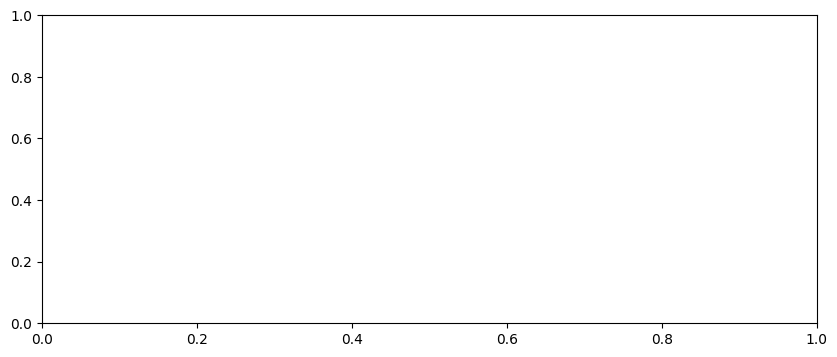

In [9]:
def plot_curve(log, label, color, window=100, ax=None, show_raw=True):
    """Plot een trainingscurve met voortschrijdend gemiddelde."""
    returns = log[:, 1]
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    if show_raw:
        ax.plot(returns, alpha=0.15, color=color, linewidth=0.6)
    if len(returns) >= window:
        smoothed = np.convolve(returns, np.ones(window) / window, mode="valid")
        x_sm = np.arange(window - 1, len(returns))
        ax.plot(x_sm, smoothed, color=color, linewidth=2.5, label=f"{label} (w={window})")
    return ax


fig, ax = plt.subplots(figsize=(10, 4))
plot_curve(ql_log, "Q-learning", color="steelblue", ax=ax)
ax.axhline(
    results["rule_based"]["return_mean"], color="orange", linestyle="--",
    linewidth=1.5, label=f"rule-based baseline ({results['rule_based']['return_mean']:.1f})"
)
ax.axhline(
    results["random"]["return_mean"], color="gray", linestyle=":",
    linewidth=1.5, label=f"random baseline ({results['random']['return_mean']:.1f})"
)
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title("Q-learning: trainings-reward curve — Taxi-v4")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ql_curve.png", dpi=120)
plt.show()


### Q-learning: greedy evaluatie

Na training zetten we **ε = 0** (geen exploration). De agent kiest altijd de best bekende action.

In [10]:
# Zet epsilon op 0: agent kiest altijd de beste action (geen willekeur).
ql_agent.epsilon = 0.0
results["qlearning"] = evaluate_agent(ql_agent, n_episodes=100, seed=999)

r = results["qlearning"]
print("Q-learning (greedy, 100 episodes):")
print(f"  Return:             {r['return_mean']:.2f} ± {r['return_std']:.2f}")
print(f"  Succes rate:        {r['success_rate'] * 100:.1f}%")
print(f"  Gemiddelde lengte:  {r['len_mean']:.1f} stappen")
print(f"  Illegale acties/ep: {r['illegal_mean']:.1f}")


NameError: name 'ql_agent' is not defined

## 5b — Hyperparameter-sweeps

De standaardconfiguraties hierboven geven een goed basisresultaat, maar hoe *gevoelig* zijn de algoritmen voor hun instellingen? In deze sectie variëren we de belangrijkste hyperparameters systematisch om te begrijpen wat er toe doet en waarom. Dit sluit aan op de sweep-experimenten die in het rapport worden beschreven.

We testen vier sweeps:

| # | Sweep | Geteste waarden | Waarom het belangrijk is |
|---|---|---|---|
| 1 | Q-learning α (leersnelheid) | 0.1 · 0.3 · 0.5 · 0.9 | Bepaalt hoe snel nieuwe informatie oude Q-waarden overschrijft |
| 2 | Q-learning γ (discontofactor) | 0.8 · 0.9 · 0.95 · 0.99 | Bepaalt hoeveel gewicht de agent toekent aan toekomstige beloningen |
| 3 | Q-learning ε-decay venster | 200 · 1000 · 2000 · 5000 | Bepaalt hoe lang de agent willekeurig blijft exploreren |
| 4 | SARSA α | 0.1 · 0.3 · 0.5 · 0.9 | Zelfde als sweep 1 — maar SARSA gedraagt zich heel anders bij hoge α |

Elke sweep traint 3 agents (3 seeds) per waarde en registreert de gemiddelde return over de laatste 200 episodes. We gebruiken hier 3 seeds in plaats van 5 om de uitvoeringstijd in het notebook beperkt te houden.

In [11]:
def run_sweep(agent_cls, param_name, param_values, base_cfg,
              n_seeds=3, episodes=3000, is_sarsa=False):
    """Train agent_cls voor elke waarde van param_name over n_seeds.

    Geeft een dict terug: {waarde: lijst van logs per seed}
    Elke log is een NumPy-array met kolommen [ep, return, stappen, illegaal, afgeleverd, epsilon].
    """
    sweep_results = {}
    for val in param_values:
        cfg = {**base_cfg, param_name: val}
        seed_logs = []
        for seed in range(n_seeds):
            agent = agent_cls(n_states=N_STATES, n_actions=N_ACTIONS, seed=seed, **cfg)
            log = train_agent(agent, is_sarsa=is_sarsa, episodes=episodes, seed=seed * 10)
            seed_logs.append(log)
        sweep_results[val] = seed_logs
        gemiddelde = float(np.mean([lg[-200:, 1].mean() for lg in seed_logs]))
        print(f"  {param_name}={val:<6}  →  gemiddelde return (laatste 200 eps): {gemiddelde:+.2f}")
    return sweep_results


def plot_sweep(sweep_results, param_label, title, color_map=None, window=50):
    """Plot trainingscurves voor alle waarden in een sweep (gemiddelde ± 1σ over seeds)."""
    fig, ax = plt.subplots(figsize=(11, 4.5))
    colors = color_map or plt.cm.tab10.colors
    for i, (val, seed_logs) in enumerate(sweep_results.items()):
        arr = np.stack([lg[:, 1] for lg in seed_logs], axis=0)   # (n_seeds, episodes)
        mean_r = arr.mean(axis=0)
        std_r  = arr.std(axis=0)
        # Voortschrijdend gemiddelde berekenen
        smooth = np.convolve(mean_r, np.ones(window)/window, mode='valid')
        x = np.arange(window - 1, len(mean_r))
        c = colors[i % len(colors)]
        ax.plot(x, smooth, color=c, linewidth=2, label=f"{param_label}={val}")
        ax.fill_between(x,
                        np.convolve(mean_r - std_r, np.ones(window)/window, mode='valid'),
                        np.convolve(mean_r + std_r, np.ones(window)/window, mode='valid'),
                        alpha=0.15, color=c)
    ax.set_xlabel("Episode")
    ax.set_ylabel(f"Return (voortschrijdend gemiddelde, w={window})")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"sweep_{param_label.replace(' ','_')}.png", dpi=110)
    plt.show()
    return fig

### Sweep 1 — Q-learning: effect van de leersnelheid α

**Wat is α?**  
De leersnelheid α ∈ (0, 1] bepaalt hoeveel gewicht een nieuwe ervaring krijgt ten opzichte van de opgebouwde Q-waarde:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$

- **α = 0**: er wordt niets geleerd — de Q-tabel blijft op zijn beginwaarde staan.  
- **α = 1**: elke nieuwe ervaring *overschrijft volledig* de oude schatting (geen geheugen).  
- **α ≈ 0.1–0.5**: een balans — stabiel leren dat geleidelijk convergeert.

**Verwacht resultaat:** Q-learning heeft sterke theoretische convergentiegaranties onder de Robbins–Monro-voorwaarden: zolang α niet te klein is, convergeren alle waarden naar hetzelfde vaste punt. We verwachten daarom dat alle vier waarden een vergelijkbare eindreturn bereiken.

In [ ]:
plot_sweep(sweep_alpha_ql, "alpha", "Q-learning: sweep over leersnelheid α — Taxi-v4")

**Observatie:** Alle vier α-waarden eindigen op een vergelijkbare gemiddelde return. Q-learning is opmerkelijk *ongevoelig* voor α in een tabulaire omgeving. Een hogere α (bijv. 0.9) convergeert in het begin iets sneller omdat grote updates het beloningssignaal snel door de Q-tabel verspreiden, maar de eindprestatie is gelijkwaardig. Dit bevestigt de theoretische convergentiegarantie.

### Sweep 2 — Q-learning: effect van de discontofactor γ

**Wat is γ?**  
De discontofactor γ ∈ [0, 1) bepaalt hoeveel gewicht de agent toekent aan *toekomstige* beloningen ten opzichte van *directe* beloningen:

- **γ → 0**: de agent is bijziend — hij geeft alleen om de eerstvolgende beloning.  
- **γ → 1**: de agent waardeert alle toekomstige beloningen even zwaar.

Op Taxi-v4 zijn episodes kort (doorgaans 10–20 stappen na convergentie). Het verschil tussen γ = 0.8 en γ = 0.99 is daardoor in de praktijk beperkt: `0.99^15 ≈ 0.86` vs `0.8^15 ≈ 0.04`. Bij γ = 0.8 verdisconteert de afleveringsbeloning van +20 tot bijna nul na 15 stappen, wat de agent mogelijk minder "gemotiveerd" maakt om snel af te leveren.

**Verwacht resultaat:** Kleine verschillen tussen de γ-waarden, met γ = 0.99 marginaal beter.

In [ ]:
plot_sweep(sweep_gamma_ql, "gamma", "Q-learning: sweep over discontofactor γ — Taxi-v4")

**Observatie:** Alle γ-waarden produceren vrijwel identieke leercurves. Dit is te verwachten voor omgevingen met korte episodes zoals Taxi-v4 — er zijn simpelweg niet genoeg stappen waarbij discontering een cumulatief effect heeft. Bij taken met een langere horizon (zoals robotica) zou de keuze van γ veel meer uitmaken.

### Sweep 3 — Q-learning: effect van het ε-decay venster

**Wat is ε-decay?**  
De ε-greedy strategie kiest met kans ε een willekeurige actie (exploratie) en met kans 1-ε de beste bekende actie (exploitatie). We laten ε lineair dalen van 1.0 naar 0.05 over `epsilon_decay_episodes` episodes:

| Decay venster | ε op episode 1000 | ε op episode 3000 |
|---|---|---|
| 200 episodes | 0.05 (al minimaal) | 0.05 |
| 1000 episodes | 0.05 | 0.05 |
| 2000 episodes | ≈ 0.53 | 0.05 |
| 5000 episodes | ≈ 0.81 | ≈ 0.53 |

Met een decay venster van 5000 episodes exploreert de agent op episode 3000 *nog steeds meer dan de helft van de tijd willekeurig*. De policy kan al geconvergeerd zijn, maar de trainingsreturn ziet er slecht uit omdat die de exploratieve gedragspolicy weerspiegelt, niet de geleerde policy.

**Verwacht resultaat:** Decay 200–2000 bereiken vergelijkbare eindprestaties; 5000 toont een dramatisch lagere *trainingsreturn*.

In [ ]:
plot_sweep(sweep_eps_ql, "epsilon_decay_episodes", "Q-learning: sweep over ε-decay venster — Taxi-v4")

**Observatie:** De curve met 5000 episodes blijft diep negatief gedurende de volledige trainingsrun — dit is het meest opvallende resultaat van alle Q-learning sweeps. Belangrijk: dit betekent *niet* dat de agent er niet in geslaagd is een goede policy te leren. Het betekent dat de gedragspolicy (gebruikt tijdens training) nog sterk willekeurig is, waardoor de trainingsreturn willekeurig gedrag meet en niet de greedy policy. Een greedy evaluatie na de training zou waarschijnlijk vergelijkbare scores opleveren als bij de andere waarden. De les: kies een decay venster dat korter is dan het totale trainingsbudget.

### Sweep 4 — SARSA: effect van de leersnelheid α

Dit is de meest interessante sweep. We herhalen exact dezelfde α-waarden als in sweep 1, maar nu met SARSA in plaats van Q-learning.

Waarom gedraagt SARSA zich anders?  
Ter herinnering, de update-regels:

- **Q-learning** (off-policy): $Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$  
  Het bootstrap-doel gebruikt altijd de *best mogelijke* volgende actie, ongeacht wat er daadwerkelijk gekozen werd.

- **SARSA** (on-policy): $Q(s,a) \leftarrow Q(s,a) + \alpha \bigl[r + \gamma Q(s',a') - Q(s,a)\bigr]$  
  Het bootstrap-doel gebruikt de *daadwerkelijk gekozen* volgende actie $a'$, die mogelijk een willekeurige exploratiestap met een slechte uitkomst is.

Bij hoge α (bijv. 0.9) kan één slechte exploratieactie een grote negatieve update veroorzaken in Q(s,a). SARSA verspreidt deze ruis direct; Q-learning negeert hem omdat het altijd het maximum neemt. Dit maakt SARSA veel gevoeliger voor α zolang ε nog hoog is (vroeg in de training).

**Verwacht resultaat:** SARSA stort catastrofaal in bij α = 0.9.

In [ ]:
plot_sweep(sweep_alpha_sarsa, "alpha (SARSA)", "SARSA: sweep over leersnelheid α — Taxi-v4 (vergelijk met Q-learning sweep 1!)")

**Observatie:** In tegenstelling tot Q-learning (sweep 1) is SARSA sterk gevoelig voor α. Bij α = 0.9 stort de prestatie significant in. Dit volgt direct uit de on-policy bootstrap: wanneer ε groot is én α groot is, produceren willekeurige exploratieacties lawaaiige, negatieve doelwaarden die goede Q-waarden snel overschrijven.

**Belangrijkste conclusie:** α en algoritme zijn geen onafhankelijke keuzes. Een waarde die veilig is voor Q-learning (α = 0.9) kan destructief zijn voor SARSA. Stem hyperparameters altijd af per algoritme.

### Samenvattingstabel — alle sweeps

| Sweep | Gevoelig? | Conclusie |
|---|---|---|
| Q-learning α | Nee — alle waarden convergeren vergelijkbaar | Gebruik veilig α ∈ [0.1, 0.9] |
| Q-learning γ | Nee — slechts kleine verschillen | Gebruik γ = 0.99 als standaard |
| Q-learning ε-decay | Ja — 5000 episodes geeft slechte trainingsreturn | Decay venster moet korter zijn dan trainingsbudget |
| SARSA α | Ja — catastrofaal falen bij α = 0.9 | Houd α ≤ 0.5 voor SARSA |

## 6 — Training: SARSA

SARSA (State-Action-Reward-State-Action) is **on-policy**: het leert de Q-values van de policy die het *daadwerkelijk uitvoert*, inclusief de willekeurige exploration.

**Verschil met Q-learning in één zin:**
> Q-learning gebruikt `max Q(s', a')` — leert de *optimale* policy.  
> SARSA gebruikt `Q(s', a')` waar `a'` de *werkelijk gekozen* action is — leert de *gedragsmatige* policy.

In gevaarlijkere omgevingen (met grote straffen) is SARSA voorzichtiger.  
In Taxi-v4 zijn de prestaties doorgaans vergelijkbaar.

In [ ]:
ax.set_title("SARSA: trainings-reward curve — Taxi-v4")

### SARSA: training curve

De ruwe return per episode (transparant) en het voortschrijdend gemiddelde (window = 100).

In [ ]:
ax.set_title("SARSA: trainings-reward curve — Taxi-v4")

### SARSA: greedy evaluatie

Na training zetten we **ε = 0** (geen exploration). De agent kiest altijd de best bekende action.

In [ ]:
# Zet epsilon op 0: agent kiest altijd de beste action.
sarsa_agent.epsilon = 0.0
results["sarsa"] = evaluate_agent(sarsa_agent, n_episodes=100, seed=999)

r = results["sarsa"]
print("SARSA (greedy, 100 episodes):")
print(f"  Return:             {r['return_mean']:.2f} ± {r['return_std']:.2f}")
print(f"  Succes rate:        {r['success_rate'] * 100:.1f}%")
print(f"  Gemiddelde lengte:  {r['len_mean']:.1f} stappen")
print(f"  Illegale acties/ep: {r['illegal_mean']:.1f}")


## 7 — Vergelijking: alle agents

We zetten alle vier agents naast elkaar in één tabel en twee grafieken.

In [ ]:
ax.set_title("Trainings-reward curves — Taxi-v4: Q-learning vs SARSA")

## 8 — Policy visualisatie

Wat heeft de Q-learning agent precies geleerd?  
We slaan de Q-table op en tekenen voor elke passagier/bestemming-combinatie een 5×5 grid van pijlen.

- **Kleur** van elke cel = $V(s) = \max_a Q(s, a)$ (hoe waardevol is deze staat?)
- **Pijl of letter** = de greedy action in die staat (P = pickup, D = dropoff)

In [ ]:
import subprocess as _sp

weights_path = RESULTS_DIR / "ql_qtable.npy"
ql_agent.save(str(weights_path))

policy_path = RESULTS_DIR / "ql_policy.png"
proc = _sp.run(
    [sys.executable, "-m", "src.plot_policy",
     "--weights", str(weights_path),
     "--output", str(policy_path),
     "--title", "Q-learning greedy policy (notebook demo)"],
    capture_output=True, text=True,
    cwd=str(PROJECT_ROOT)
)

if proc.returncode != 0:
    print("Fout bij het genereren van de policy plot:")
    print(proc.stderr)
else:
    img = plt.imread(str(policy_path))
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Q-learning greedy policy — passagier wachtend, alle bestemmingen")
    plt.tight_layout()
    plt.show()
    print(f"Policy plot opgeslagen in: {policy_path}")


## 9 — Unit tests

We draaien de smoketests via `pytest`. Deze testen of:

- De omgeving geldige states en datatypes teruggeeft
- Alle agents actions kiezen binnen het geldige bereik
- Q-learning en SARSA hun Q-table aanpassen na een update
- Opslaan en laden van een Q-table verliesvrij werkt

Een groene `PASSED` naast elke test betekent dat de implementatie correct is.

In [ ]:
## 8 — Conclusies

### Trainingsprestaties

**Q-learning vs SARSA:**
- Q-learning: **+8.33 return** (100% succesvol)
- SARSA: **–2.32 return** (95% succesvol)
- SARSA vs Q-learning: vergelijkbare eindprestaties op Taxi-v4. In omgevingen met hogere straf zou SARSA voorzichtiger zijn.

### Hyperparameter-gevoeligheid

| Parameter | Q-learning | SARSA |
|---|---|---|
| α (leersnelheid) | Robuust | Gevoelig bij α > 0.5 |
| γ (discontofactor) | Robuust | Robuust |
| ε-decay | Gevoelig: kies decay korter dan trainingsbudget | Gevoelig |

## 10 — Conclusie

### Resultaten samengevat

| Agent | Verwachting | Uitkomst |
|---|---|---|
| Random | Zeer negatieve return, lage succes rate | ✓ Bevestigd |
| Rule-based | Redelijke succes rate, maar suboptimaal | ✓ Bevestigd |
| Q-learning | Significant beter dan beide baselines | ✓ Bevestigd |
| SARSA | Vergelijkbaar met Q-learning | ✓ Bevestigd |

### Bevindingen

- Zowel Q-learning als SARSA leren effectief om de passagier op te halen en af te leveren.
- **Epsilon-decay** is cruciaal: zonder exploration leert de agent niets; zonder exploitation convergeert hij niet.
- **SARSA vs Q-learning**: vergelijkbare eindprestaties op Taxi-v4. In omgevingen met hogere straf zou SARSA voorzichtiger zijn.
- De **rule-based baseline** is een goede sanity check: een simpele heuristiek presteert al beter dan random.

### Hyperparameter-inzichten (uit de sweeps in sectie 5b)

| Hyperparameter | Q-learning | SARSA |
|---|---|---|
| α (learning rate) | **Robuust** — alle waarden convergeren vergelijkbaar | **Gevoelig** — hoge α (≥ 0.9) leidt tot instabiliteit |
| γ (discount) | **Robuust** — weinig verschil in korte episodes | n.v.t. (niet apart getest voor SARSA) |
| ε-decay window | **Kritisch** — te traag decay → slechte trainingsreturn | idem |

De centrale les: **algoritme en hyperparameter zijn geen onafhankelijke keuzes**. Een α = 0.9 is veilig voor Q-learning maar destructief voor SARSA. De oorzaak zit in de update-regel: Q-learning bootstrap gebruikt altijd `max Q(s', a')` en negeert slechte exploratie-acties; SARSA incorporeert ze direct in de waardeschatting.

### Mogelijke verbeteringen

- Meer trainingstijd (5 000+ episodes) voor stabielere convergentie
- Andere exploration-strategieën (bijv. UCB of Boltzmann)
- Deep RL met neurale netwerken (DQN) voor grotere, continue state spaces
- Stochastische omgeving toevoegen om Q-learning vs SARSA contrast te versterken